##Celda 0 — Montar Google Drive

Conecta Google Colab con tu Google Drive para poder acceder al dataset almacenado en la nube. Es necesario ejecutar esta celda primero y autorizar el acceso.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


##  Celda 1 — Importar librerías

Carga todas las herramientas necesarias para el proyecto:
- **numpy / pandas**: manipulación de datos y álgebra lineal
- **matplotlib**: visualización de gráficas
- **sklearn**: división del dataset en entrenamiento/prueba
- **scipy**: optimización matemática avanzada

In [ ]:
# utilizado para la manipulación de directorios y rutas
import os

# Cálculo científico y vectorial para python
import numpy as np
import pandas as pd
# Libreria para graficos
+3
from matplotlib import pyplot
from sklearn.model_selection import train_test_split
# Modulo de optimizacion en scipy
from scipy import optimize

# modulo para cargar archivos en formato MATLAB
# from scipy.io import loadmat

# le dice a matplotlib que incruste gráficos en el cuaderno
%matplotlib inline

##  Celda 2 — Cargar y preprocesar el dataset NSL-KDD

Esta es la celda más importante de preparación. Realiza los siguientes pasos:

1. **Define 43 columnas** del dataset (características del tráfico de red)
2. **Carga el archivo** `.txt` desde Google Drive
3. **Mapea etiquetas** de texto a 5 clases numéricas:
   - `0` → Normal
   - `1` → DoS (Denegación de Servicio)
   - `2` → Probe (Escaneo de red)
   - `3` → R2L (Acceso remoto no autorizado)
   - `4` → U2R (Escalada de privilegios)
4. **One-Hot Encoding**: convierte columnas de texto en columnas binarias, expandiendo el dataset a 122 columnas
5. **División 80%/20%** con `stratify` para representar todas las clases
6. **Balanceo**: toma 15,000 muestras por clase para evitar sesgo hacia clases mayoritarias

In [ ]:

# La entrada es de 14 elemento contando con x0
input_layer_size  = 122

# 10 etiquetas, de 1 a 10 (tomar en cuenta que se asigna "0" a la etiqueta 10)
num_labels = 5
# 1. Definir los nombres de las 43 columnas originales del dataset NSL-KDD

nombres_columnas = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins", "logged_in",
    "num_compromised", "root_shell", "su_attempted", "num_root", "num_file_creations",
    "num_shells", "num_access_files", "num_outbound_cmds", "is_host_login",
    "is_guest_login", "count", "srv_count", "serror_rate", "srv_serror_rate",
    "rerror_rate", "srv_rerror_rate", "same_srv_rate", "diff_srv_rate",
    "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count",
    "dst_host_same_srv_rate", "dst_host_diff_srv_rate", "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate", "dst_host_serror_rate", "dst_host_srv_serror_rate",
    "dst_host_rerror_rate", "dst_host_srv_rerror_rate", "label", "difficulty_level"
]

# 2. Cargar el dataset usando Pandas
# ¡OJO! Cambia esta ruta por la ruta real de tu archivo en Drive
ruta_dataset = '/content/drive/MyDrive/Colab Notebooks/sis420/Laboratorios/Lab 4/lab 4(1)/KDDTrain+.txt'
df = pd.read_csv(ruta_dataset, names=nombres_columnas)

# Eliminar la columna de dificultad (no es una característica del tráfico, es meta-información)
df = df.drop('difficulty_level', axis=1)

# 3. Agrupar los tipos de ataque en las 5 clases principales (0 al 4)
mapa_clases = {
    'normal': 0,
    # DoS (Denegación de servicio) -> Clase 1
    'neptune': 1, 'smurf': 1, 'pod': 1, 'teardrop': 1, 'land': 1, 'back': 1, 'apache2': 1, 'udpstorm': 1, 'processtable': 1, 'worm': 1, 'mailbomb': 1,
    # Probe (Sondeo) -> Clase 2
    'satan': 2, 'ipsweep': 2, 'portsweep': 2, 'nmap': 2, 'mscan': 2, 'saint': 2,
    # R2L (Acceso remoto no autorizado) -> Clase 3
    'guess_passwd': 3, 'ftp_write': 3, 'imap': 3, 'phf': 3, 'multihop': 3, 'warezmaster': 3, 'warezclient': 3, 'spy': 3, 'xlock': 3, 'xsnoop': 3, 'snmpguess': 3, 'snmpgetattack': 3, 'httptunnel': 3, 'sendmail': 3, 'named': 3, 'dict': 3,
    # U2R (Acceso a superusuario) -> Clase 4
    'buffer_overflow': 4, 'rootkit': 4, 'loadmodule': 4, 'perl': 4, 'sqlattack': 4, 'xterm': 4, 'ps': 4
}

# Aplicar el mapa. Si hay algún ataque raro no mapeado, lo ponemos como 0 por seguridad
df['label'] = df['label'].map(mapa_clases).fillna(0).astype(int)

# 4. Convertir texto a números (One-Hot Encoding)
# Las columnas 'protocol_type', 'service' y 'flag' tienen texto. Esto las vuelve columnas de 0s y 1s.
df = pd.get_dummies(df, columns=['protocol_type', 'service', 'flag'], dtype=float)

print("--- Preprocesamiento Inicial ---")
print(f"Tamaño actual del dataset: {df.shape[0]} filas y {df.shape[1]} columnas.")

# ====================================================================
# 5. DIVIDIR 80/20 PRIMERO (Aleatorio para evitar sesgos de orden)
# ====================================================================
X_completo = df.drop('label', axis=1).values
y_completo = df['label'].values

# Usamos train_test_split en lugar de 'limite' para mezclar los datos y asegurar
# que haya de todas las clases tanto en entrenamiento como en prueba (stratify)
X_train_raw, X_test, y_train_raw, y_test = train_test_split(
    X_completo, y_completo, test_size=0.20, random_state=42, stratify=y_completo
)

# ====================================================================
# 6. BALANCEAR ÚNICAMENTE EL 80% DE ENTRENAMIENTO
# ====================================================================
# Metemos el 80% (X_train_raw y y_train_raw) a un DataFrame temporal para usar Pandas
df_train = pd.DataFrame(X_train_raw, columns=df.drop('label', axis=1).columns)
df_train['label'] = y_train_raw

muestras_por_clase = 15000
df_balanceado = df_train.groupby('label').apply(lambda x: x.sample(muestras_por_clase, replace=True)).reset_index(drop=True)

print("\n--- Balanceo de Clases (Solo en el 80% de Entrenamiento) ---")
print(df_balanceado['label'].value_counts().sort_index())

# ====================================================================
# 7. ASIGNAR LAS VARIABLES FINALES PARA TU MODELO
# ====================================================================
# Extraemos tus matrices definitivas listas para el gradiente
X = df_balanceado.drop('label', axis=1).values
y = df_balanceado['label'].values

print("\n--- Resumen Final de Matrices ---")
print(f"Tamaño de X (Entrenamiento balanceado): {X.shape}")
print(f"Tamaño de y: {y.shape}")
print(f"Tamaño de X_test (Prueba intacta 20%): {X_test.shape}")
print(f"Tamaño de y_test: {y_test.shape}")

--- Preprocesamiento Inicial ---
Tamaño actual del dataset: 125973 filas y 123 columnas.

--- Balanceo de Clases (Solo en el 80% de Entrenamiento) ---
label
0    15000
1    15000
2    15000
3    15000
4    15000
Name: count, dtype: int64

--- Resumen Final de Matrices ---
Tamaño de X (Entrenamiento balanceado): (75000, 122)
Tamaño de y: (75000,)
Tamaño de X_test (Prueba intacta 20%): (25195, 122)
Tamaño de y_test: (25195,)


/tmp/ipykernel_39690/3880192144.py:72: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_balanceado = df_train.groupby('label').apply(lambda x: x.sample(muestras_por_clase, replace=True)).reset_index(drop=True)


##  Celda 3 — Visualizar datos cargados

Imprime los valores de la matriz `X` (características) y el vector `y` (etiquetas) para verificar que el preprocesamiento fue correcto.

In [ ]:
print(X)
print(y)

[[0.000e+00 3.830e+02 0.000e+00 ... 0.000e+00 1.000e+00 0.000e+00]
 [0.000e+00 0.000e+00 0.000e+00 ... 0.000e+00 0.000e+00 0.000e+00]
 [0.000e+00 0.000e+00 0.000e+00 ... 0.000e+00 0.000e+00 0.000e+00]
 ...
 [6.000e+01 8.600e+01 1.830e+02 ... 0.000e+00 1.000e+00 0.000e+00]
 [0.000e+00 0.000e+00 5.928e+03 ... 0.000e+00 1.000e+00 0.000e+00]
 [0.000e+00 4.000e+00 0.000e+00 ... 0.000e+00 1.000e+00 0.000e+00]]
[0 0 0 ... 4 4 4]


##  Celda 4 — Normalización de características (`featureNormalize`)

Normaliza cada columna usando la fórmula: `X_norm = (X - mu) / sigma`

Esto garantiza que todas las características tengan **media 0 y desviación estándar 1**, evitando que columnas con valores grandes (como `src_bytes`) dominen sobre columnas pequeñas (como `land`). Si alguna columna es constante (`sigma == 0`), se reemplaza por 1 para evitar división por cero.

In [ ]:
def featureNormalize(X):
    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)

    # --- SOLUCIÓN AL ERROR ---
    # Buscamos dónde sigma es exactamente 0 y lo cambiamos por 1
    # Esto evita la división por cero.
    sigma[sigma == 0] = 1
    # -------------------------

    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

## ⚙️ Celda 5 — Aplicar normalización

Llama a `featureNormalize` con los datos de entrenamiento y guarda `mu` y `sigma` para usarlos también al normalizar los datos de prueba más adelante.

In [ ]:
# llama featureNormalize con los datos cargados
X_norm, mu, sigma = featureNormalize(X)

##  Celda 6 — Verificar datos normalizados

Muestra `X_norm` e `y` para confirmar que la normalización fue aplicada correctamente.

In [ ]:
print(X_norm)
print(y)

[[-0.16239473 -0.01657624 -0.01177551 ... -0.03184904  0.66485365
  -0.07459304]
 [-0.16239473 -0.01661882 -0.01177551 ... -0.03184904 -1.50409041
  -0.07459304]
 [-0.16239473 -0.01661882 -0.01177551 ... -0.03184904 -1.50409041
  -0.07459304]
 ...
 [-0.14655617 -0.01660926 -0.01175901 ... -0.03184904  0.66485365
  -0.07459304]
 [-0.16239473 -0.01661882 -0.01124105 ... -0.03184904  0.66485365
  -0.07459304]
 [-0.16239473 -0.01661837 -0.01177551 ... -0.03184904  0.66485365
  -0.07459304]]
[0 0 0 ... 4 4 4]


##  Celda 7 — Preparar matriz X

Asigna los datos normalizados a la variable `X` lista para el entrenamiento. El término de sesgo (columna de unos) se agrega dentro de las funciones `OneVsAll`, no aquí.

In [ ]:
# Configurar la matriz adecuadamente, y agregar una columna de unos que corresponde al termino de intercepción.
m, n = X.shape
# Agraga el termino de intercepción a A
# X = np.concatenate([np.ones((m, 1)), X_norm], axis=1)
X = X_norm
# X = np.concatenate([np.ones((m, 1)), X], axis=1)

##  Celda 8 — Función Sigmoide

Implementa la función: `σ(z) = 1 / (1 + e^(-z))`

Convierte cualquier número real en un valor entre **0 y 1**, interpretable como probabilidad. Es la función de activación central de la regresión logística.

In [ ]:
def sigmoid(z):
    """
    Calcula la sigmoide de z.
    """
    return 1.0 / (1.0 + np.exp(-z))

##  Celda 9 — Función de Costo (`calcularCosto`)

Calcula qué tan mal está el modelo usando la **entropía cruzada binaria**:

`J = -(1/m) · Σ [ y·log(h) + (1-y)·log(1-h) ]`

Si el modelo predice correctamente, el costo es bajo. Se agrega `ε = 1e-15` para evitar `log(0)` que causaría error matemático.

In [ ]:
def calcularCosto(theta, X, y):
    m = y.size
    h = sigmoid(X.dot(theta))
    # Añadimos 1e-15 para evitar log(0)
    epsilon = 1e-15
    J = (1 / m) * np.sum(-y * np.log(h + epsilon) - (1 - y) * np.log(1 - h + epsilon))
    return J

##  Celda 10 — Descenso de Gradiente (`descensoGradiente`)

Optimiza los parámetros `theta` iterativamente durante `num_iters` iteraciones:

1. Calcula predicciones con la sigmoide: `h = σ(X·θ)`
2. Actualiza theta: `θ = θ - (α/m) · (h - y) · X`
3. Registra historial de **costo** y **precisión** en cada iteración para graficar la convergencia.

In [ ]:
def descensoGradiente(theta, X, y, alpha, num_iters):
    # Inicializa algunos valores
    m = y.shape[0] # numero de ejemplos de entrenamiento

    # realiza una copia de theta, el cual será acutalizada por el descenso por el gradiente
    theta = theta.copy()
    J_history = []
    acc_history = [] # NUEVO: Historial de precisión
    for i in range(num_iters):
        h = sigmoid(X.dot(theta.T))
        theta = theta - (alpha / m) * (h - y).dot(X)

        J_history.append(calcularCosto(theta, X, y))
        # NUEVO: Calculamos y guardamos la precisión
        # h >= 0.5 se considera predicción positiva (1), h < 0.5 es negativa (0)
        predicciones = (h >= 0.5).astype(int)
        precision = np.mean(predicciones == y) * 100
        acc_history.append(precision)
    return theta, J_history, acc_history

##  Celda 11 — Costo Regularizado (`lrCostFunction`)

Versión mejorada del costo que agrega **regularización L2** (Ridge):

`J_reg = J + (λ/2m) · Σθ²`

El parámetro `λ` (lambda) penaliza valores de `theta` muy grandes, previniendo el sobreajuste (overfitting). El término de sesgo `θ[0]` no se regulariza, siguiendo la convención estándar.

In [ ]:
def lrCostFunction(theta, X, y, lambda_):
    """
    Calcula el costo de usar theta como parámetro para la regresión logística regularizada y
    el gradiente del costo w.r.t. a los parámetros.

    Parametros
    ----------
    theta : array_like
        Parametro theta de la regresion logistica. Vector de la forma(shape) (n, ). n es el numero de caracteristicas
        incluida la intercepcion

    X : array_like
        Dataset con la forma(shape) (m x n). m es el numero de ejemplos, y n es el numero de
        caracteristicas (incluida la intercepcion).

    y : array_like
        El conjunto de etiquetas. Un vector con la forma (shape) (m, ). m es el numero de ejemplos

    lambda_ : float
        Parametro de regularización.

    Devuelve
    -------
    J : float
        El valor calculado para la funcion de costo regularizada.

    grad : array_like
        Un vector de la forma (shape) (n, ) que es el gradiente de la
        función de costo con respecto a theta, en los valores actuales de theta..
    """
#     alpha = 0.003
#     theta = theta.copy()
    # Inicializa algunos valores utiles
    m = y.size

    # convierte las etiquetas a valores enteros si son boleanos
    if y.dtype == bool:
        y = y.astype(int)

    J = 0
    grad = np.zeros(theta.shape)

    h = sigmoid(X.dot(theta.T))

    temp = theta
    temp[0] = 0
    h = np.clip(h, 1e-15, 1 - 1e-15)
#     J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))
    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h))) + (lambda_ / (2 * m)) * np.sum(np.square(temp))

    grad = (1 / m) * (h - y).dot(X)
#     theta = theta - (alpha / m) * (h - y).dot(X)
    grad = grad + (lambda_ / m) * temp

    return J, grad
#    return J, theta

##  Celda 12 — Entrenamiento One-vs-All (`OneVsAll`)

Núcleo del modelo multiclase. Entrena **un clasificador por cada clase** (5 en total):

- Cada clasificador aprende a distinguir su clase vs. todas las demás
- Usa descenso de gradiente con `α = 0.1` y `6000` iteraciones
- Genera dos gráficas al finalizar:
  - **Curva de Costo**: muestra cómo baja el error por clase
  - **Curva de Precisión**: muestra cómo sube la exactitud por clase

In [ ]:
def OneVsAll(X, y, num_labels, lambda_):
    alpha = 0.1
    num_iters = 6000

    m, n = X.shape
    all_theta = np.zeros((num_labels, n + 1))
    X = np.concatenate([np.ones((m, 1)), X], axis=1)

    all_J_hist   = []   # historial de costo por clase
    all_acc_hist = []   # historial de precisión por clase
    nombres_clases = ['Normal', 'DoS', 'Probe', 'R2L', 'U2R']
    colores = ['#1f77b4', '#d62728', '#2ca02c', '#ff7f0e', '#9467bd']

    for c in np.arange(num_labels):
        initial_theta = np.zeros(n + 1)
        y_actual = np.where(y == c, 1, 0)

        theta, J_history, acc_history = descensoGradiente(
            initial_theta, X, y_actual, alpha, num_iters)

        all_theta[c] = theta
        all_J_hist.append(J_history)      # solo guardar, NO graficar aquí
        all_acc_hist.append(acc_history)  # igual para precisión

    iteraciones = np.arange(1, num_iters + 1)

    # ── GRÁFICA 1: Curva del Costo ─────────────────────────────────────
    fig1, ax1 = pyplot.subplots(figsize=(10, 6))
    for c in range(num_labels):
        ax1.plot(iteraciones, all_J_hist[c],
                 lw=2, color=colores[c],
                 label=f'Clase {c}: {nombres_clases[c]}')
    ax1.set_xlabel('Número de iteraciones')
    ax1.set_ylabel('Costo J')
    ax1.set_title('Curva del Costo — One-vs-All NSL-KDD')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.5)
    pyplot.tight_layout()
    pyplot.show()

    # ── GRÁFICA 2: Curva de Precisión ─────────────────────────────────
    fig2, ax2 = pyplot.subplots(figsize=(10, 6))
    for c in range(num_labels):
        ax2.plot(iteraciones, all_acc_hist[c],
                 lw=2, color=colores[c],
                 label=f'Clase {c}: {nombres_clases[c]}')
    ax2.set_xlabel('Número de iteraciones')
    ax2.set_ylabel('Precisión (%)')
    ax2.set_title('Curva de Precisión — One-vs-All NSL-KDD')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.5)
    pyplot.tight_layout()
    pyplot.show()

    return all_theta

##  Celda 13 — Alternativa con `scipy.optimize` (`OneVsAllOM`)

Hace lo mismo que `OneVsAll` pero usa el optimizador **Gradiente Conjugado (CG)** de `scipy` en lugar del descenso de gradiente manual. Es matemáticamente más eficiente pero aquí se limita a 10 iteraciones. Útil para comparar rendimiento con el método manual.

In [ ]:
def OneVsAllOM(X, y, num_labels, lambda_):
    """
    Trains num_labels logistic regression classifiers and returns
    each of these classifiers in a matrix all_theta, where the i-th
    row of all_theta corresponds to the classifier for label i.

    Parameters
    ----------
    X : array_like
        The input dataset of shape (m x n). m is the number of
        data points, and n is the number of features. Note that we
        do not assume that the intercept term (or bias) is in X, however
        we provide the code below to add the bias term to X.

    y : array_like
        The data labels. A vector of shape (m, ).

    num_labels : int
        Number of possible labels.

    lambda_ : float
        The logistic regularization parameter.

    Returns
    -------
    all_theta : array_like
        The trained parameters for logistic regression for each class.
        This is a matrix of shape (K x n+1) where K is number of classes
        (ie. `numlabels`) and n is number of features without the bias.
    """
    # algunas variables utiles
    m, n = X.shape

    all_theta = np.zeros((num_labels, n + 1))

    # Agrega unos a la matriz X
    X = np.concatenate([np.ones((m, 1)), X], axis=1)

    for c in np.arange(num_labels):
        initial_theta = np.zeros(n + 1)

        options = {'maxiter': 10}
        res = optimize.minimize(lrCostFunction,
                                initial_theta,
                                (X, (y == c), lambda_),
                                jac=True,
                                method='CG',
                                options=options)

        all_theta[c] = res.x


    return all_theta

##  Celda 14 — Ejecutar el entrenamiento

Llama a `OneVsAll` con `λ = 0.1` para entrenar los 5 clasificadores. El resultado es la matriz `all_theta` de forma `(5, 123)`: una fila de parámetros por cada clase.

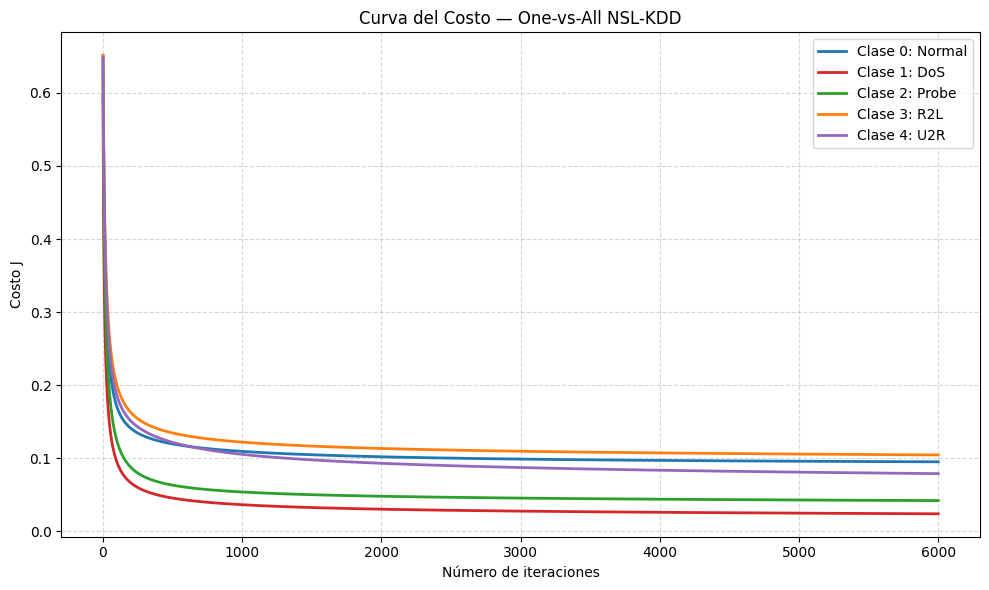

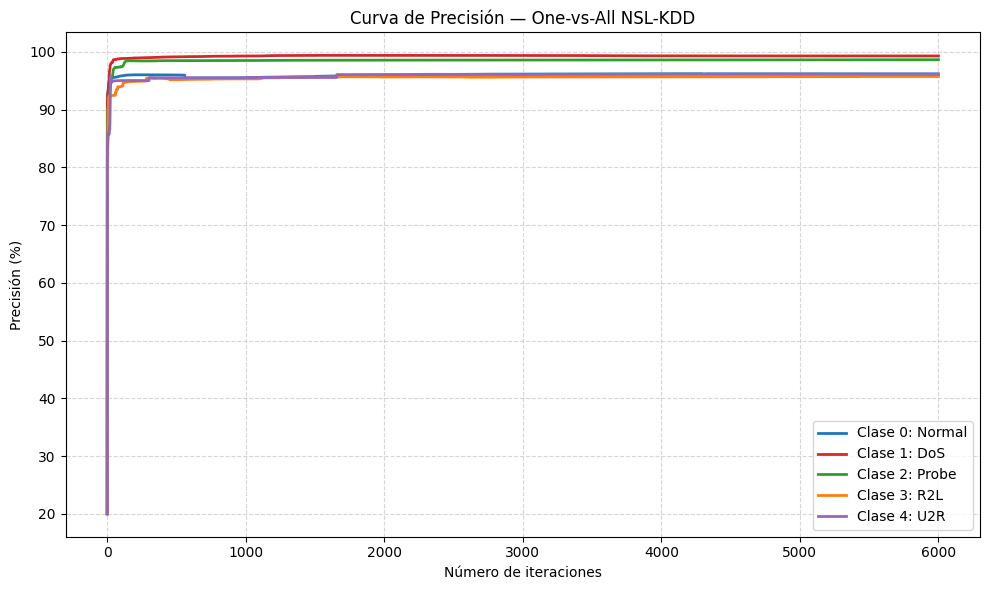

(5, 123)


In [ ]:
lambda_ = 0.1
all_theta1 = OneVsAll(X, y, num_labels, lambda_)

print(all_theta1.shape)

##  Celda 15 — Ver parámetros aprendidos

Muestra la matriz `all_theta` con todos los parámetros aprendidos por el modelo durante el entrenamiento.

In [ ]:

print(all_theta1)

[[-3.83464349e+00  1.56065789e-01 -2.40122264e-01 -5.92328795e-02
   1.08152485e-01 -2.69158678e-01  2.60093699e-02 -7.47929538e-01
  -1.72634244e-01 -7.26066712e-01  2.56096931e-01 -9.22098120e-01
   1.19221985e-01  3.68615483e-01  1.00553620e-01 -7.33678815e-02
  -1.50424540e-01  0.00000000e+00  0.00000000e+00  4.13277220e-01
  -9.91156090e-01  3.59826299e-01 -5.54106644e-01 -6.03833800e-01
  -1.80094592e-01 -3.92388040e-01  1.71102052e-01  1.89694143e-01
  -1.66992341e-01 -8.04066288e-01  1.91005175e+00 -1.34262971e+00
   3.45500766e-01 -7.52815932e-01 -3.76588457e-01  4.15136160e-02
  -8.27177780e-02 -6.96541050e-01  2.38424039e-01 -3.24829996e-01
   1.40334906e-01  1.38552876e-01  1.86889463e-01  8.09058573e-02
  -2.61719087e-02  0.00000000e+00  1.93659739e-01 -2.93308716e-02
  -3.84509375e-02 -1.34268669e-02 -7.94108237e-02 -7.52138693e-02
  -3.18475986e-02 -1.63439012e-02  8.59902389e-01 -2.96130530e-02
  -3.48603785e-01 -1.48812680e-01 -3.90103978e-02 -6.39872525e-02
   9.07479

##  Celda 16 — Función de Predicción (`predictOneVsAll`)

Dada la matriz de parámetros entrenados, predice la clase de cada ejemplo:

1. Calcula la probabilidad de pertenecer a cada una de las 5 clases
2. Asigna la **clase con probabilidad más alta** usando `np.argmax`

Resultado: vector `p` con valores entre 0 y 4 (una clase por ejemplo).

In [ ]:
def predictOneVsAll(all_theta, X):
    """
    Devuelve un vector de predicciones para cada ejemplo en la matriz X.
    Tenga en cuenta que X contiene los ejemplos en filas.
    all_theta es una matriz donde la i-ésima fila es un vector theta de regresión logística entrenada para la i-ésima clase.
    Debe establecer p en un vector de valores de 0..K-1 (por ejemplo, p = [0, 2, 0, 1]
    predice clases 0, 2, 0, 1 para 4 ejemplos).

    Parametros
    ----------
    all_theta : array_like
        The trained parameters for logistic regression for each class.
        This is a matrix of shape (K x n+1) where K is number of classes
        and n is number of features without the bias.

    X : array_like
        Data points to predict their labels. This is a matrix of shape
        (m x n) where m is number of data points to predict, and n is number
        of features without the bias term. Note we add the bias term for X in
        this function.

    Devuelve
    -------
    p : array_like
        The predictions for each data point in X. This is a vector of shape (m, ).
    """

    m = X.shape[0];
    num_labels = all_theta.shape[0]

    p = np.zeros(m)

    # Add ones to the X data matrix
    X = np.concatenate([np.ones((m, 1)), X], axis=1)
    p = np.argmax(sigmoid(X.dot(all_theta.T)), axis = 1)

    return p

##  Celda 17 — Evaluación del modelo

Calcula y muestra la precisión del modelo:

- **Precisión en entrenamiento**: compara predicciones con etiquetas reales del conjunto balanceado
- **Evaluación en prueba**: normaliza `X_test` usando la misma `mu` y `sigma` del entrenamiento (importante: no recalcular en datos de prueba) y genera predicciones sobre el 20% de datos no vistos

In [ ]:
print(X.shape)
pred = predictOneVsAll(all_theta1, X)
print('Precision del conjuto de entrenamiento: {:.2f}%'.format(np.mean(pred == y) * 100))
print('dimenciones de la prueba a realisarse: ',X_test.shape)
#print(np.ones((1)))
#print(XPrueba)
#p = np.zeros(1)
X_test_norm = (X_test - mu) / sigma
XPrueba = np.concatenate([np.ones((X_test_norm.shape[0], 1)), X_test_norm], axis=1)
p = np.argmax(sigmoid(XPrueba.dot(all_theta1.T)), axis = 1)

(75000, 122)
Precision del conjuto de entrenamiento: 93.60%
dimenciones de la prueba a realisarse:  (25195, 122)


##  Celda 18 — Comparación predicción vs. realidad

Muestra una tabla con los primeros 100 pares `(predicción, etiqueta real)` para inspeccionar visualmente la calidad del clasificador. Permite identificar en qué tipos de ataque el modelo comete más errores.

In [ ]:
# Combinar las predicciones (p) y las etiquetas originales (y_test) en dos columnas
resultados_comparacion = np.column_stack((p, y_test))

# Imprimir los primeros 10 pares para su visualización
print("Predicción | Original")
print("---------- | ---------")
for i in range(min(100, len(resultados_comparacion))):
    print(f"{resultados_comparacion[i][0]:^10} | {resultados_comparacion[i][1]:^9}")

# Puedes ajustar el número de elementos a mostrar según sea necesario
# Para ver todo, simplemente puedes imprimir `resultados_comparacion`

Predicción | Original
---------- | ---------
    0      |     0    
    3      |     3    
    0      |     0    
    0      |     0    
    1      |     1    
    0      |     1    
    0      |     0    
    0      |     0    
    0      |     0    
    0      |     0    
    0      |     0    
    1      |     1    
    0      |     0    
    2      |     2    
    2      |     2    
    1      |     1    
    1      |     1    
    1      |     1    
    1      |     1    
    2      |     2    
    0      |     0    
    1      |     1    
    0      |     0    
    4      |     0    
    0      |     0    
    0      |     0    
    0      |     0    
    0      |     0    
    2      |     0    
    1      |     1    
    1      |     1    
    1      |     1    
    1      |     1    
    1      |     1    
    1      |     1    
    0      |     0    
    1      |     1    
    0      |     0    
    1      |     1    
    2      |     0    
    1      |     1    
    1      |